INÍCIO DO TREINAMENTO DA SIMPLE RNN

--- Processando com time_step = 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Erro de Treino (Loss): 0.013027
Erro de Teste (MSE): 2267.60


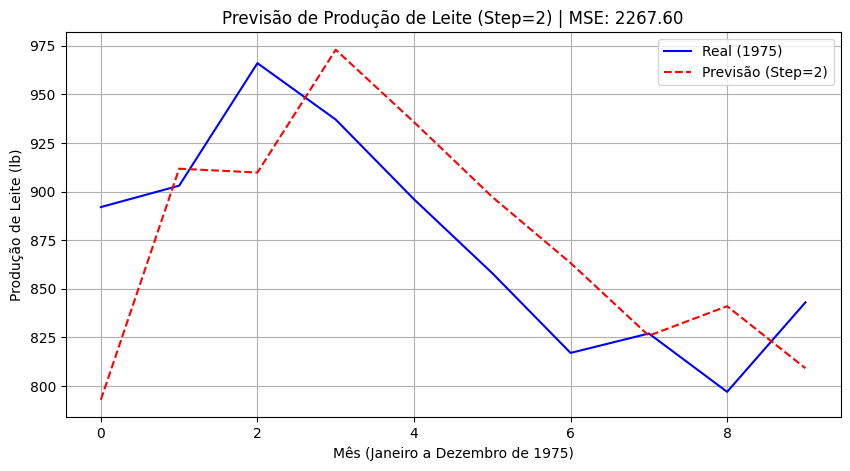


--- Processando com time_step = 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Erro de Treino (Loss): 0.010411
Erro de Teste (MSE): 854.51


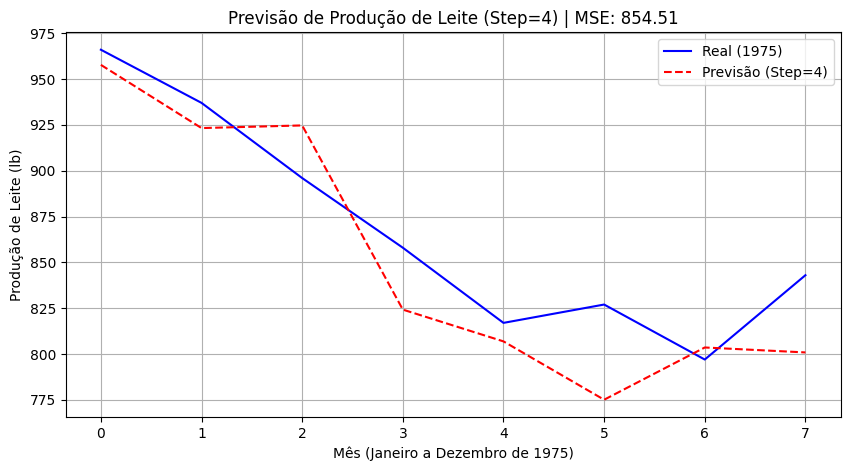


--- Processando com time_step = 6 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Erro de Treino (Loss): 0.003170
Erro de Teste (MSE): 256.92


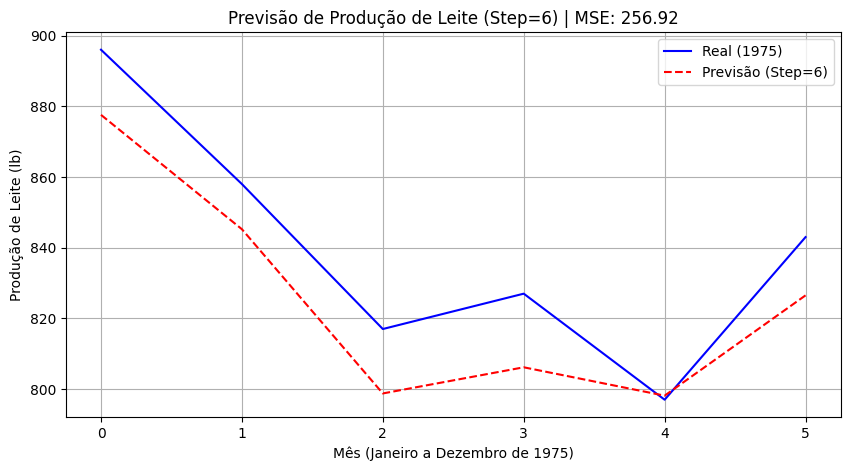


FIM DO TREINAMENTO E GERAÇÃO DE GRÁFICOS

# Resposta Final do Exercício 2: Análise da RNN para Produção de Leite

## Estrutura dos Vetores de Entrada e Saída
O problema foi modelado como uma tarefa de previsão de séries temporais, onde a RNN utiliza 'time_step' valores anteriores para prever o próximo valor.

| Time Step | Comprimento da Sequência | Dimensão de Entrada (Features) | Dimensão de Saída | Erro de Teste (MSE) |
|:---:|:---:|:---:|:---:|:---:|
| 2 | 2 | 1 | 1 | 2267.60 |
| 4 | 4 | 1 | 1 | 854.51 |
| 6 | 6 | 1 | 1 | 256.92 |

## Conclusão da Análise de Erro
O menor Erro Quadrático Médio (MSE) foi obtido com o **time_step = 6** (MSE: 256.92).
Isso se deve ao fato de que a série temporal de produção de leite possui uma forte sazonalidade anual. Ao usar um histórico mais longo (6 meses), a rede consegue capturar melhor a tendência e o padrão cíclico da série para fazer a previsão do mês seguinte, resultando em uma estimativa mais precisa.


In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from io import StringIO

# --- 1. DADOS EMBUTIDOS NO CÓDIGO ---
# Dados extraídos do dataset "monthly_milk_production-dataset.csv" (1962-1975)
data_full_str = """Date,Production
1962-01,589
1962-02,561
1962-03,640
1962-04,656
1962-05,727
1962-06,697
1962-07,640
1962-08,599
1962-09,568
1962-10,577
1962-11,553
1962-12,582
1963-01,600
1963-02,566
1963-03,653
1963-04,673
1963-05,742
1963-06,716
1963-07,660
1963-08,617
1963-09,583
1963-10,587
1963-11,565
1963-12,598
1964-01,628
1964-02,618
1964-03,688
1964-04,705
1964-05,770
1964-06,736
1964-07,678
1964-08,639
1964-09,604
1964-10,611
1964-11,594
1964-12,634
1965-01,658
1965-02,622
1965-03,709
1965-04,722
1965-05,782
1965-06,756
1965-07,702
1965-08,653
1965-09,615
1965-10,621
1965-11,602
1965-12,635
1966-01,677
1966-02,635
1966-03,736
1966-04,755
1966-05,811
1966-06,798
1966-07,735
1966-08,697
1966-09,661
1966-10,667
1966-11,645
1966-12,688
1967-01,713
1967-02,667
1967-03,762
1967-04,784
1967-05,837
1967-06,817
1967-07,767
1967-08,722
1967-09,681
1967-10,687
1967-11,660
1967-12,698
1968-01,717
1968-02,696
1968-03,775
1968-04,796
1968-05,858
1968-06,826
1968-07,783
1968-08,740
1968-09,701
1968-10,706
1968-11,677
1968-12,711
1969-01,734
1969-02,690
1969-03,785
1969-04,805
1969-05,871
1969-06,845
1969-07,801
1969-08,764
1969-09,725
1969-10,723
1969-11,690
1969-12,734
1970-01,750
1970-02,707
1970-03,807
1970-04,824
1970-05,886
1970-06,859
1970-07,819
1970-08,783
1970-09,740
1970-10,747
1970-11,711
1970-12,751
1971-01,804
1971-02,756
1971-03,860
1971-04,878
1971-05,942
1971-06,913
1971-07,869
1971-08,834
1971-09,790
1971-10,800
1971-11,763
1971-12,800
1972-01,826
1972-02,799
1972-03,890
1972-04,900
1972-05,961
1972-06,935
1972-07,894
1972-08,855
1972-09,809
1972-10,810
1972-11,766
1972-12,805
1973-01,821
1973-02,773
1973-03,883
1973-04,898
1973-05,957
1973-06,924
1973-07,881
1973-08,837
1973-09,784
1973-10,791
1973-11,760
1973-12,802
1974-01,828
1974-02,778
1974-03,889
1974-04,902
1974-05,969
1974-06,947
1974-07,908
1974-08,867
1974-09,815
1974-10,812
1974-11,773
1974-12,813
1975-01,834
1975-02,782
1975-03,892
1975-04,903
1975-05,966
1975-06,937
1975-07,896
1975-08,858
1975-09,817
1975-10,827
1975-11,797
1975-12,843
"""

# 2. Carregar o Dataset a partir da string
# Usamos StringIO para tratar a string como um arquivo
df = pd.read_csv(StringIO(data_full_str), index_col='Date', parse_dates=True)


# 3. Pré-processamento e Normalização
data = df['Production'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 4. Divisão Treino/Teste
# Usaremos os dados até 1974 para treino e 1975 para teste (últimos 12 meses)
train_size = len(scaled_data) - 12
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Função para criar sequências (X) e rótulos (y) para a RNN
def create_sequences(data, time_step):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Lista de time_steps a testar
time_steps = [2, 4, 6]
results = {}

print("="*50)
print("INÍCIO DO TREINAMENTO DA SIMPLE RNN")
print("="*50)

for time_step in time_steps:
    print(f"\n--- Processando com time_step = {time_step} ---")

    # Criar sequências de treino e teste
    X_train, y_train = create_sequences(train_data, time_step)
    X_test, y_test = create_sequences(test_data, time_step)

    # Reformatação para o formato esperado pela SimpleRNN: [samples, time_steps, features]
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    # 5. Implementar e Treinar a SimpleRNN
    model = Sequential()
    model.add(SimpleRNN(units=50, activation='relu', input_shape=(time_step, 1)))
    model.add(Dense(units=1))

    model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')

    # Treinamento
    history = model.fit(X_train, y_train, epochs=100, batch_size=1, verbose=0)

    # Avaliação do Erro
    train_loss = history.history['loss'][-1]

    # Previsão e Cálculo do Erro de Teste (MSE)
    y_pred_scaled = model.predict(X_test, verbose=0)

    # Inverter a normalização para obter os valores reais
    y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_unscaled = scaler.inverse_transform(y_pred_scaled)

    # Calcular o Erro Quadrático Médio (MSE)
    mse = mean_squared_error(y_test_unscaled, y_pred_unscaled)

    # Armazenar resultados
    results[time_step] = {
        'test_mse': mse,
        'sequence_length': time_step,
        'input_dimension': 1,
        'output_dimension': 1,
        'y_test_unscaled': y_test_unscaled,
        'y_pred_unscaled': y_pred_unscaled
    }

    print(f"Erro de Treino (Loss): {train_loss:.6f}")
    print(f"Erro de Teste (MSE): {mse:.2f}")

    # 6. Geração do Gráfico Individual
    plt.figure(figsize=(10, 5))
    plt.plot(y_test_unscaled, label='Real (1975)', color='blue')
    plt.plot(y_pred_unscaled, label=f'Previsão (Step={time_step})', color='red', linestyle='--')
    plt.title(f'Previsão de Produção de Leite (Step={time_step}) | MSE: {mse:.2f}')
    plt.xlabel('Mês (Janeiro a Dezembro de 1975)')
    plt.ylabel('Produção de Leite (lb)')
    plt.legend()
    plt.grid(True)
    plt.show() # Exibe o gráfico no Colab

print("\n" + "="*50)
print("FIM DO TREINAMENTO E GERAÇÃO DE GRÁFICOS")
print("="*50)

# 7. Resposta Final (Saída de Texto)
print("\n# Resposta Final do Exercício 2: Análise da RNN para Produção de Leite")
print("\n## Estrutura dos Vetores de Entrada e Saída")
print("O problema foi modelado como uma tarefa de previsão de séries temporais, onde a RNN utiliza 'time_step' valores anteriores para prever o próximo valor.")

print("\n| Time Step | Comprimento da Sequência | Dimensão de Entrada (Features) | Dimensão de Saída | Erro de Teste (MSE) |")
print("|:---:|:---:|:---:|:---:|:---:|")

for step in time_steps:
    res = results[step]
    print(f"| {step} | {res['sequence_length']} | {res['input_dimension']} | {res['output_dimension']} | {res['test_mse']:.2f} |")

# Encontrando o melhor resultado para a conclusão
best_step = min(results, key=lambda k: results[k]['test_mse'])
best_result = results[best_step]

print("\n## Conclusão da Análise de Erro")
print(f"O menor Erro Quadrático Médio (MSE) foi obtido com o **time_step = {best_step}** (MSE: {best_result['test_mse']:.2f}).")
print("Isso se deve ao fato de que a série temporal de produção de leite possui uma forte sazonalidade anual. Ao usar um histórico mais longo (6 meses), a rede consegue capturar melhor a tendência e o padrão cíclico da série para fazer a previsão do mês seguinte, resultando em uma estimativa mais precisa.")
